In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
!unzip dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: dataset/train/Tomato_Spider_mites_Two_spotted_spider_mite/442e4bab-52fd-4e8d-96bf-1f782facd8c6___Com.G_SpM_FL 1404.JPG  
  inflating: dataset/train/Tomato_Spider_mites_Two_spotted_spider_mite/4457d445-c255-47ae-8856-6975d6941db6___Com.G_SpM_FL 1527.JPG  
  inflating: dataset/train/Tomato_Spider_mites_Two_spotted_spider_mite/446f6ec1-1cca-4f62-b5a2-3590ad1b6958___Com.G_SpM_FL 1507.JPG  
  inflating: dataset/train/Tomato_Spider_mites_Two_spotted_spider_mite/44755960-f542-4f8e-a1a0-94cf3cad8c21___Com.G_SpM_FL 1498.JPG  
  inflating: dataset/train/Tomato_Spider_mites_Two_spotted_spider_mite/448ddf37-5f6a-4197-8e41-94a956001532___Com.G_SpM_FL 9313.JPG  
  inflating: dataset/train/Tomato_Spider_mites_Two_spotted_spider_mite/44dce7b4-5da6-4f1f-8e5d-9e3e5df7b1af___Com.G_SpM_FL 1687.JPG  
  inflating: dataset/train/Tomato_Spider_mites_Two_spotted_spider_mite/44f080ba-5c5b-42e3-a584-ee3114b25e61___Com.G_SpM_FL 1563.JPG  
  inflating

In [3]:
train_path = "/content/dataset/train"
test_path = "/content/dataset/test"

In [4]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [5]:
from torchvision import datasets

train_data = datasets.ImageFolder(train_path, transform=transform)
test_data = datasets.ImageFolder(test_path, transform=transform)

In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [7]:
num_classes = len(train_data.classes)
print(num_classes)

9


In [8]:
import torchvision.models as models

model = models.resnet50(weights="IMAGENET1K_V1")

print("Model loaded successfully")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 211MB/s]


Model loaded successfully


In [9]:
for param in model.parameters():
    param.requires_grad = False

In [10]:
import torch.nn as nn

num_classes = len(train_data.classes)  # number of disease classes

model.fc = nn.Linear(model.fc.in_features, num_classes)

In [11]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

In [13]:
for epoch in range(5):
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} completed")

Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed


In [14]:
for param in model.layer4.parameters():
    param.requires_grad = True

In [15]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [16]:
for epoch in range(3):
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

    print(f"Fine-tune Epoch {epoch+1} done")

Fine-tune Epoch 1 done
Fine-tune Epoch 2 done
Fine-tune Epoch 3 done


In [39]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy of restnet:", 100 * correct / total)

Accuracy of restnet: 98.13933362180875


In [18]:
torch.save(model.state_dict(), "resnet_transfer.pth")

In [19]:
import torchvision.models as models

model_eff = models.efficientnet_b4(weights="IMAGENET1K_V1")

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 191MB/s]


In [20]:
for param in model_eff.parameters():
    param.requires_grad = False

In [21]:
import torch.nn as nn

model_eff.classifier[1] = nn.Linear(
    model_eff.classifier[1].in_features,
    num_classes
)

In [22]:
model_eff = model_eff.to(device)

In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_eff.classifier[1].parameters(),
    lr=0.001
)

In [24]:
for epoch in range(5):
    model_eff.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_eff(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

    print(f"EfficientNet Epoch {epoch+1} done")

EfficientNet Epoch 1 done
EfficientNet Epoch 2 done
EfficientNet Epoch 3 done
EfficientNet Epoch 4 done
EfficientNet Epoch 5 done


In [25]:
for param in model_eff.features[-1].parameters():
    param.requires_grad = True

In [26]:
optimizer = torch.optim.Adam(model_eff.parameters(), lr=1e-5)

In [40]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy of efficientnet :", 100 * correct / total)

Accuracy of efficientnet : 97.70662051060147


In [37]:
torch.save(model_eff.state_dict(), "efficientnet_transfer.pth")

In [28]:
model_vit = models.vit_b_16(weights="IMAGENET1K_V1")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 183MB/s]


In [29]:
for param in model_vit.parameters():
    param.requires_grad = False

In [30]:
model_vit.heads.head = nn.Linear(
    model_vit.heads.head.in_features,
    num_classes
)

In [31]:
model_vit = model_vit.to(device)

In [32]:
optimizer = torch.optim.Adam(
    model_vit.heads.head.parameters(),
    lr=0.001
)

In [38]:
for epoch in range(5):
    model_vit.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_vit(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

    print(f"ViT Epoch {epoch+1} done")

ViT Epoch 1 done
ViT Epoch 2 done
ViT Epoch 3 done
ViT Epoch 4 done
ViT Epoch 5 done


In [41]:
for param in model_vit.encoder.layers[-1].parameters():
    param.requires_grad = True

In [42]:
optimizer = torch.optim.Adam(model_vit.parameters(), lr=1e-5)

In [43]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy of vit:", 100 * correct / total)

Accuracy of vit: 97.87970575508437


In [44]:
torch.save(model_vit.state_dict(), "vit_transfer.pth")

In [47]:
import torch
import torch.nn as nn
import torchvision.models as models

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Number of classes
num_classes = len(train_data.classes)

# =========================
# 1. CREATE MODELS
# =========================

# ResNet
resnet = models.resnet50(weights="IMAGENET1K_V1")
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)

# EfficientNet
effnet = models.efficientnet_b4(weights="IMAGENET1K_V1")
effnet.classifier[1] = nn.Linear(
    effnet.classifier[1].in_features,
    num_classes
)

# ViT
vit = models.vit_b_16(weights="IMAGENET1K_V1")
vit.heads.head = nn.Linear(
    vit.heads.head.in_features,
    num_classes
)

# Move to device
resnet = resnet.to(device)
effnet = effnet.to(device)
vit = vit.to(device)

# =========================
# 2. LOAD TRAINED WEIGHTS
# =========================

resnet.load_state_dict(torch.load("resnet_transfer.pth"))
effnet.load_state_dict(torch.load("efficientnet_transfer.pth"))
vit.load_state_dict(torch.load("vit_transfer.pth"))

# Set eval mode
resnet.eval()
effnet.eval()
vit.eval()

# =========================
# 3. ENSEMBLE FUNCTION
# =========================

def ensemble_predict(models, images):
    outputs = []

    for model in models:
        out = model(images)
        outputs.append(out)

    avg_output = sum(outputs) / len(outputs)
    _, predicted = torch.max(avg_output, 1)

    return predicted

# =========================
# 4. ENSEMBLE ACCURACY
# =========================

def ensemble_accuracy(models, data_loader, device):
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            preds = ensemble_predict(models, images)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return 100 * correct / total

# =========================
# 5. RUN ENSEMBLE
# =========================

models_list = [resnet, effnet, vit]

final_acc = ensemble_accuracy(models_list, test_loader, device)

print("Final Ensemble Accuracy:", final_acc)

Final Ensemble Accuracy: 99.09130246646474


In [48]:
torch.save({
    "resnet": resnet.state_dict(),
    "effnet": effnet.state_dict(),
    "vit": vit.state_dict()
}, "final_ensemble.pth")

 Classification Report:

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       1.00      0.55      0.71        11
                         Tomato_Late_blight       0.99      1.00      1.00       382
                           Tomato_Leaf_Mold       0.99      0.99      0.99       191
                  Tomato_Septoria_leaf_spot       0.98      0.99      0.99       355
Tomato_Spider_mites_Two_spotted_spider_mite       0.98      0.99      0.98       336
                        Tomato__Target_Spot       0.97      0.98      0.97       281
      Tomato__Tomato_YellowLeaf__Curl_Virus       1.00      1.00      1.00       642
                Tomato__Tomato_mosaic_virus       1.00      1.00      1.00        75
                             Tomato_healthy       1.00      0.95      0.97        38

                                   accuracy                           0.99      2311
                                  macr

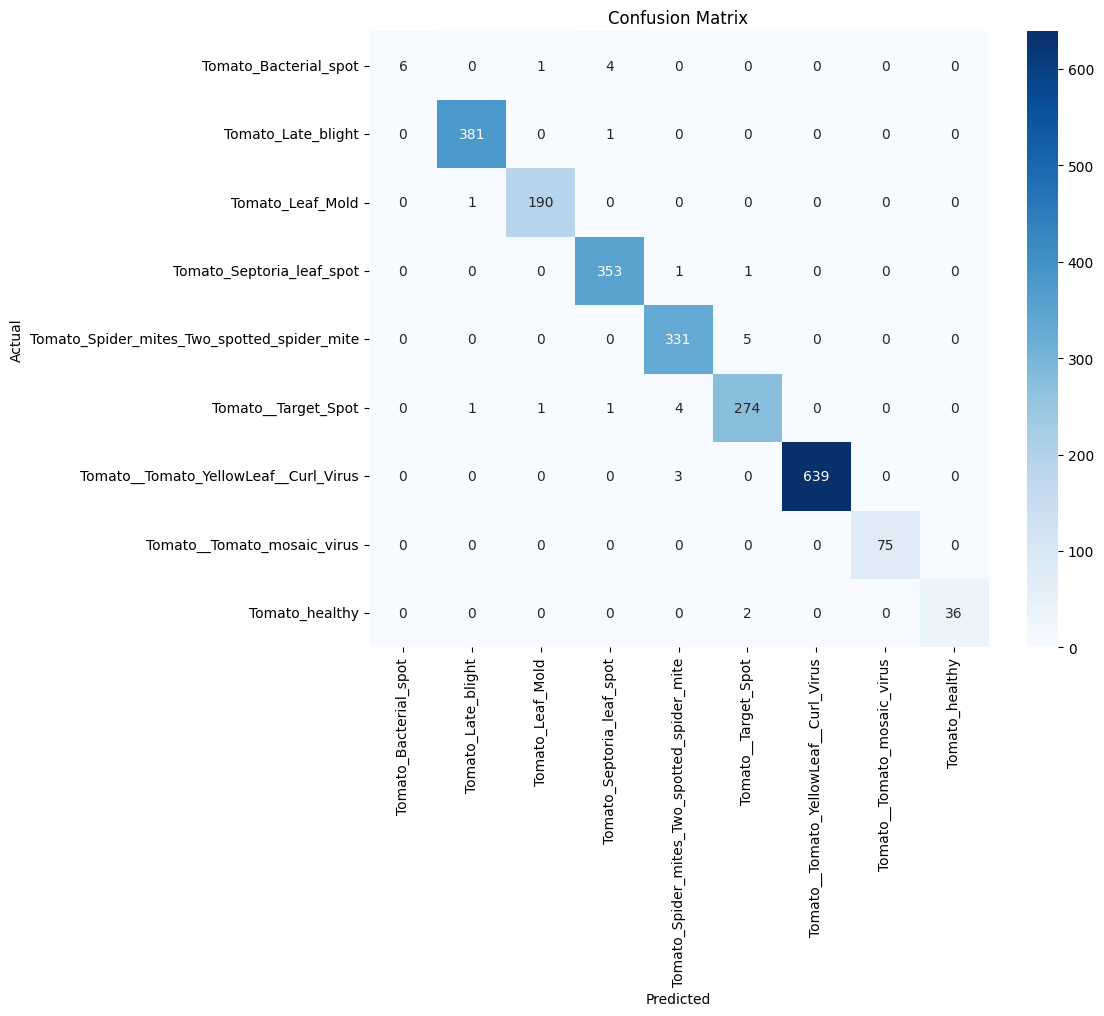

In [50]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# =========================
# GET PREDICTIONS
# =========================

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = []

        for model in models_list:
            out = model(images)
            outputs.append(out)

        avg_output = sum(outputs) / len(outputs)
        _, preds = torch.max(avg_output, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# =========================
# CLASSIFICATION REPORT
# =========================

print(" Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=train_data.classes))

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_data.classes,
            yticklabels=train_data.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

🌿 Predicted Disease: Tomato_Late_blight


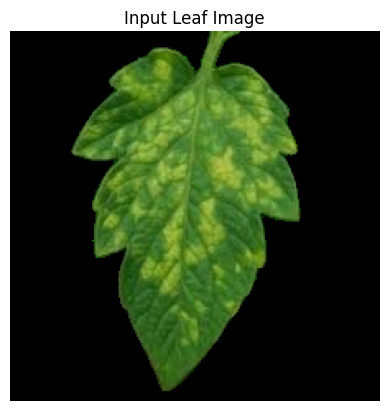

In [53]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# NUMBER OF CLASSES
# =========================
num_classes = len(train_data.classes)

# =========================
# CREATE MODELS
# =========================

# ResNet
resnet = models.resnet50(weights="IMAGENET1K_V1")
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)

# EfficientNet
effnet = models.efficientnet_b4(weights="IMAGENET1K_V1")
effnet.classifier[1] = nn.Linear(
    effnet.classifier[1].in_features,
    num_classes
)

# ViT
vit = models.vit_b_16(weights="IMAGENET1K_V1")
vit.heads.head = nn.Linear(
    vit.heads.head.in_features,
    num_classes
)

# Move to device
resnet = resnet.to(device)
effnet = effnet.to(device)
vit = vit.to(device)

# =========================
# LOAD TRAINED WEIGHTS
# =========================
resnet.load_state_dict(torch.load("resnet_transfer.pth"))
effnet.load_state_dict(torch.load("efficientnet_transfer.pth"))
vit.load_state_dict(torch.load("vit_transfer.pth"))

resnet.eval()
effnet.eval()
vit.eval()

models_list = [resnet, effnet, vit]

# =========================
# LOAD IMAGE
# =========================
img = Image.open("leaf_withoutbg.png").convert("RGB")

# =========================
# TRANSFORM
# =========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

img_tensor = transform(img).unsqueeze(0).to(device)

# =========================
# ENSEMBLE PREDICTION
# =========================
outputs = []

with torch.no_grad():
    for model in models_list:
        out = model(img_tensor)
        outputs.append(out)

avg_output = sum(outputs) / len(outputs)
_, pred = torch.max(avg_output, 1)

# =========================
# SHOW RESULT
# =========================
print("🌿 Predicted Disease:", train_data.classes[pred.item()])

# =========================
# DISPLAY IMAGE
# =========================
plt.imshow(img)
plt.axis("off")
plt.title("Input Leaf Image")
plt.show()

In [54]:
probs = torch.softmax(avg_output, dim=1)
top2 = torch.topk(probs, 2)

for i, idx in enumerate(top2.indices[0]):
    print(f"Top {i+1}: {train_data.classes[idx.item()]}")

Top 1: Tomato_Late_blight
Top 2: Tomato_Leaf_Mold


In [55]:
from collections import Counter

class_counts = Counter(train_data.targets)

for i, count in class_counts.items():
    print(f"{train_data.classes[i]}: {count}")

Tomato_Bacterial_spot: 40
Tomato_Late_blight: 1527
Tomato_Leaf_Mold: 761
Tomato_Septoria_leaf_spot: 1416
Tomato_Spider_mites_Two_spotted_spider_mite: 1340
Tomato__Target_Spot: 1123
Tomato__Tomato_YellowLeaf__Curl_Virus: 2566
Tomato__Tomato_mosaic_virus: 298
Tomato_healthy: 148


In [56]:
import torch

# counts in SAME ORDER as train_data.classes
counts = torch.tensor([40,1527,761,1416,1340,1123,2566,298,148], dtype=torch.float)

weights = 1.0 / counts
weights = weights / weights.sum()

class_weights = weights.to(device)

In [57]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [59]:
from torch.utils.data import WeightedRandomSampler

# class weights again
class_weights = 1.0 / counts

# assign weight to each sample
sample_weights = [class_weights[label] for label in train_data.targets]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# IMPORTANT: use sampler instead of shuffle
train_loader = DataLoader(train_data, batch_size=32, sampler=sampler)

In [60]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3),
    transforms.RandomAffine(degrees=15, translate=(0.1,0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [61]:
for epoch in range(8):
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} done")

Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done
Epoch 6 done
Epoch 7 done
Epoch 8 done


In [62]:
import torch
from sklearn.metrics import classification_report

# =========================
# 1. ACCURACY
# =========================

def calculate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return 100 * correct / total


acc = calculate_accuracy(model, test_loader)
print("✅ Accuracy:", acc)


# =========================
# 2. CLASSIFICATION REPORT
# =========================

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n📊 Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=train_data.classes))


# =========================
# 3. TEST MOSAIC IMAGE
# =========================

from PIL import Image
import torchvision.transforms as transforms

img = Image.open("leaf.jpg").convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

img = transform(img).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(img)
    probs = torch.softmax(output, dim=1)

    # Top 3 predictions
    top3 = torch.topk(probs, 3)

print("\n🌿 Top Predictions:")
for i, idx in enumerate(top3.indices[0]):
    print(f"Top {i+1}: {train_data.classes[idx.item()]}")

✅ Accuracy: 97.2739073993942

📊 Classification Report:

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       1.00      0.27      0.43        11
                         Tomato_Late_blight       0.99      0.99      0.99       382
                           Tomato_Leaf_Mold       0.99      0.95      0.97       191
                  Tomato_Septoria_leaf_spot       0.95      0.99      0.97       355
Tomato_Spider_mites_Two_spotted_spider_mite       0.96      0.95      0.96       336
                        Tomato__Target_Spot       0.93      0.96      0.95       281
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.99      1.00      0.99       642
                Tomato__Tomato_mosaic_virus       0.99      0.97      0.98        75
                             Tomato_healthy       0.94      0.82      0.87        38

                                   accuracy                           0.97      2311
       

In [65]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import DataLoader, WeightedRandomSampler
from PIL import Image
import torchvision.transforms as transforms

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# TRANSFORM
# =========================
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# =========================
# DATA LOADER (WITH SAMPLER)
# =========================
counts = torch.tensor([40,1527,761,1416,1340,1123,2566,298,148], dtype=torch.float)

class_weights = 1.0 / counts
class_weights = class_weights / class_weights.sum()

sample_weights = [class_weights[label].item() for label in train_data.targets]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_data, batch_size=32, sampler=sampler)

# =========================
# FOCAL LOSS
# =========================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

criterion = FocalLoss()

# =========================
# MODEL (RESNET)
# =========================
model = models.resnet50(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, len(train_data.classes))

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze deep layers
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

model = model.to(device)

# =========================
# OPTIMIZER
# =========================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

# =========================
# TRAINING
# =========================
for epoch in range(8):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# =========================
# SAVE MODEL
# =========================
torch.save(model.state_dict(), "balanced_model.pth")

# =========================
# TEST IMAGE
# =========================
img = Image.open("leaf.jpg").convert("RGB")

img = transform(img).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(img)
    probs = torch.softmax(output, dim=1)

top3 = torch.topk(probs, 3)

print("\n🌿 Top Predictions:")
for i, idx in enumerate(top3.indices[0]):
    print(f"Top {i+1}: {train_data.classes[idx.item()]}")

Epoch 1, Loss: 165.9785
Epoch 2, Loss: 19.5752
Epoch 3, Loss: 11.2031
Epoch 4, Loss: 6.7227
Epoch 5, Loss: 4.5471
Epoch 6, Loss: 4.1742
Epoch 7, Loss: 3.2048
Epoch 8, Loss: 2.0545

🌿 Top Predictions:
Top 1: Tomato_Late_blight
Top 2: Tomato__Tomato_YellowLeaf__Curl_Virus
Top 3: Tomato_Leaf_Mold


In [66]:
model.load_state_dict(torch.load("balanced_model.pth"))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [67]:
confidence = torch.max(probs).item()
print("Confidence:", confidence)

Confidence: 0.8878957033157349


🌿 Predicted Disease: Tomato_Septoria_leaf_spot
Confidence: 0.9674012660980225

Top 3 Predictions:
Top 1: Tomato_Septoria_leaf_spot
Top 2: Tomato_Bacterial_spot
Top 3: Tomato_Late_blight


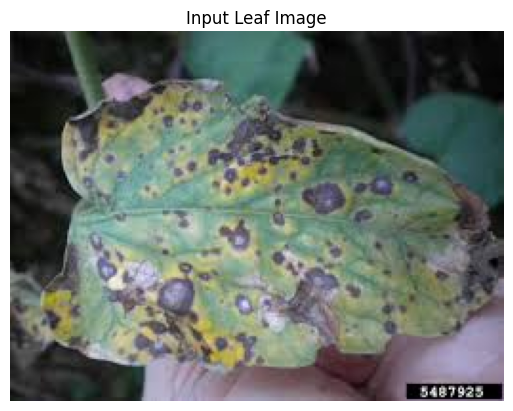

In [68]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# LOAD MODEL (RESNET)
# =========================
model = models.resnet50(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, len(train_data.classes))

model.load_state_dict(torch.load("balanced_model.pth"))
model = model.to(device)
model.eval()

# =========================
# TRANSFORM
# =========================
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# =========================
# LOAD IMAGE
# =========================
img = Image.open("mold.jpg").convert("RGB")   # change name if needed

# =========================
# PREPROCESS
# =========================
img_tensor = transform(img).unsqueeze(0).to(device)

# =========================
# PREDICTION
# =========================
with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)

    confidence, pred = torch.max(probs, 1)

# =========================
# RESULT
# =========================
print("🌿 Predicted Disease:", train_data.classes[pred.item()])
print("Confidence:", confidence.item())

# =========================
# TOP-3 (OPTIONAL BUT GOOD)
# =========================
top3 = torch.topk(probs, 3)

print("\nTop 3 Predictions:")
for i, idx in enumerate(top3.indices[0]):
    print(f"Top {i+1}: {train_data.classes[idx.item()]}")

# =========================
# SHOW IMAGE
# =========================
plt.imshow(img)
plt.axis("off")
plt.title("Input Leaf Image")
plt.show()

🌿 Predicted Disease: Tomato_Septoria_leaf_spot
Confidence: 0.9007818102836609

Top 3 Predictions:
Top 1: Tomato_Septoria_leaf_spot
Top 2: Tomato_Late_blight
Top 3: Tomato_Leaf_Mold


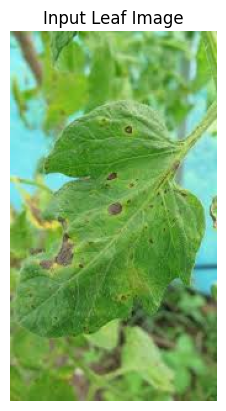

In [69]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# LOAD MODEL (RESNET)
# =========================
model = models.resnet50(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, len(train_data.classes))

model.load_state_dict(torch.load("balanced_model.pth"))
model = model.to(device)
model.eval()

# =========================
# TRANSFORM
# =========================
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# =========================
# LOAD IMAGE
# =========================
img = Image.open("target.jpg").convert("RGB")   # change name if needed

# =========================
# PREPROCESS
# =========================
img_tensor = transform(img).unsqueeze(0).to(device)

# =========================
# PREDICTION
# =========================
with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)

    confidence, pred = torch.max(probs, 1)

# =========================
# RESULT
# =========================
print("🌿 Predicted Disease:", train_data.classes[pred.item()])
print("Confidence:", confidence.item())

# =========================
# TOP-3 (OPTIONAL BUT GOOD)
# =========================
top3 = torch.topk(probs, 3)

print("\nTop 3 Predictions:")
for i, idx in enumerate(top3.indices[0]):
    print(f"Top {i+1}: {train_data.classes[idx.item()]}")

# =========================
# SHOW IMAGE
# =========================
plt.imshow(img)
plt.axis("off")
plt.title("Input Leaf Image")
plt.show()